# Foundations: Integrated Clinical + CS + Pathology Image Basics

This notebook combines:
1. Clinical reasoning for model use
2. Core machine-learning fundamentals
3. Practical pathology image/patch concepts on a real slide image


## Learning Objectives

By the end, you should be able to:
1. Translate a clinical question into an ML decision problem
2. Explain key classification metrics both intuitively and mathematically
3. Understand logistic regression and cross-entropy training
4. Extract and analyze patch crops from a pathology slide image
5. Compute simple QC and patch-level feature summaries


## Part A. Clinical Framing for Technical Learners

### A1) Clinical question -> ML task

**High-level intuition**
- Clinical teams care about missed disease and unnecessary interventions.
- ML turns this into probability estimation plus a thresholded decision.

**Math form**
- Input feature vector: $x \in \mathbb{R}^d$
- Label: $y \in \{0,1\}$
- Model output: $\hat{p}(x) \approx P(y=1\mid x)$
- Decision: predict positive when $\hat{p}(x) \ge t$


In [1]:
clinical_to_ml = {
    'Screening support': 'Binary classification with high sensitivity preference',
    'Diagnostic support': 'Probability estimation + threshold tuned to workflow',
    'Triage': 'Risk ranking and threshold-based routing',
}

for k, v in clinical_to_ml.items():
    print(f'- {k}: {v}')


- Screening support: Binary classification with high sensitivity preference
- Diagnostic support: Probability estimation + threshold tuned to workflow
- Triage: Risk ranking and threshold-based routing


### A2) Confusion matrix metrics: intuition + formulas

With counts $TP, TN, FP, FN$:

- Sensitivity (Recall):
$$
	ext{Sensitivity} = \frac{TP}{TP+FN}
$$

- Specificity:
$$
	ext{Specificity} = \frac{TN}{TN+FP}
$$

- Positive Predictive Value (PPV):
$$
	ext{PPV} = \frac{TP}{TP+FP}
$$

- Negative Predictive Value (NPV):
$$
	ext{NPV} = \frac{TN}{TN+FN}
$$

**Intuition**
- High sensitivity reduces missed disease.
- High specificity reduces false alarms.


In [2]:
import numpy as np

y_true = np.array([1,1,1,1,1,1,1,1,1,1, 0,0,0,0,0,0,0,0,0,0,
                   1,1,1,1,1, 0,0,0,0,0, 1,1,1, 0,0,0,1,0,1,0])
y_pred = np.array([1,1,1,0,1,1,1,1,0,1, 0,0,1,0,0,0,0,0,0,0,
                   1,1,0,1,1, 0,1,0,0,0, 1,0,1, 0,0,1,1,0,1,0])

tp = int(np.sum((y_true == 1) & (y_pred == 1)))
tn = int(np.sum((y_true == 0) & (y_pred == 0)))
fp = int(np.sum((y_true == 0) & (y_pred == 1)))
fn = int(np.sum((y_true == 1) & (y_pred == 0)))

def safe_div(a, b):
    return a / b if b else float('nan')

sensitivity = safe_div(tp, tp + fn)
specificity = safe_div(tn, tn + fp)
ppv = safe_div(tp, tp + fp)
npv = safe_div(tn, tn + fn)

print('TP, TN, FP, FN =', tp, tn, fp, fn)
print('Sensitivity:', round(sensitivity, 3))
print('Specificity:', round(specificity, 3))
print('PPV:', round(ppv, 3))
print('NPV:', round(npv, 3))


TP, TN, FP, FN = 16 17 3 4
Sensitivity: 0.8
Specificity: 0.85
PPV: 0.842
NPV: 0.81


### A3) Prevalence effect (Bayes view)

Let prevalence be $\pi=P(y=1)$, sensitivity $Se$, specificity $Sp$:

$$
	ext{PPV}=\frac{Se\,\pi}{Se\,\pi + (1-Sp)(1-\pi)}
$$

$$
	ext{NPV}=\frac{Sp(1-\pi)}{(1-Se)\pi + Sp(1-\pi)}
$$

PPV can change a lot when prevalence changes, even if the model itself is unchanged.


In [3]:
Se, Sp = 0.90, 0.85
prevalences = np.array([0.01, 0.05, 0.10, 0.20, 0.40])

print('prev   PPV    NPV')
for pi in prevalences:
    ppv_val = (Se * pi) / (Se * pi + (1 - Sp) * (1 - pi))
    npv_val = (Sp * (1 - pi)) / ((1 - Se) * pi + Sp * (1 - pi))
    print(f'{pi:>4.2f}  {ppv_val:>5.3f}  {npv_val:>5.3f}')


prev   PPV    NPV
0.01  0.057  0.999
0.05  0.240  0.994
0.10  0.400  0.987
0.20  0.600  0.971
0.40  0.800  0.927


## Part B. CS/ML Fundamentals for Medical Learners

### B1) Data representation

- Feature matrix $X \in \mathbb{R}^{n	imes d}$
- Label vector $y \in \{0,1\}^n$
- Learn parameters $	heta$ to map $X 
ightarrow y$


In [4]:
rng = np.random.default_rng(7)
n, d = 300, 8
X = rng.normal(size=(n, d))

logits = 1.1 * X[:, 0] - 0.8 * X[:, 1] + 0.25 * X[:, 2] + 0.2 * rng.normal(size=n)
y = (logits > 0).astype(int)

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Positive class rate:', round(float(y.mean()), 3))


X shape: (300, 8)
y shape: (300,)
Positive class rate: 0.5


### B2) Logistic regression: equation and loss

For one sample $x$:

$$
z = w^T x + b, \quad \hat{p}=\sigma(z)=\frac{1}{1+e^{-z}}
$$

Binary cross-entropy for sample $i$:

$$
\ell_i = -\left[y_i\log\hat{p}_i + (1-y_i)\log(1-\hat{p}_i)
\right]
$$

Dataset objective with $L_2$ regularization:

$$
J(w,b)=\frac{1}{n}\sum_{i=1}^n \ell_i + \lambda\|w\|_2^2
$$


In [5]:
# Minimal from-scratch logistic regression demo on first 2 features
X2 = X[:, :2]
y2 = y

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def loss_and_grads(X, y, w, b, l2=0.0):
    n = X.shape[0]
    z = X @ w + b
    p = np.clip(sigmoid(z), 1e-8, 1 - 1e-8)
    loss = -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)) + l2 * np.sum(w * w)

    dz = (p - y) / n
    grad_w = X.T @ dz + 2 * l2 * w
    grad_b = float(np.sum(dz))
    return loss, grad_w, grad_b

w = np.zeros(X2.shape[1])
b = 0.0
lr = 0.5

for step in range(1, 301):
    loss, gw, gb = loss_and_grads(X2, y2, w, b, l2=0.01)
    w -= lr * gw
    b -= lr * gb
    if step in (1, 20, 50, 100, 200, 300):
        print(f'step={step:>3d}  loss={loss:.4f}')


step=  1  loss=0.6931
step= 20  loss=0.3612
step= 50  loss=0.3259
step=100  loss=0.3211
step=200  loss=0.3208
step=300  loss=0.3208


### B3) Proper evaluation and leakage warning

Train/test split should happen before any transform that learns from data.
Use a pipeline so preprocessing is fit on training data only.


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

proper = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])
proper.fit(X_train, y_train)
pred = proper.predict(X_test)

print('Test accuracy:', round(float(accuracy_score(y_test, pred)), 3))


Test accuracy: 0.95


## Part C. Pathology Image Basics (Real Slide Crop Workflow)

### C1) Load slide image


In [7]:
from pathlib import Path
import matplotlib.pyplot as plt

candidates = [
    Path('assets/images/slide.jpg'),
    Path('../../assets/images/slide.jpg'),
    Path('../assets/images/slide.jpg'),
]
slide_path = next((p for p in candidates if p.exists()), None)
if slide_path is None:
    raise FileNotFoundError('Could not find assets/images/slide.jpg')

slide = plt.imread(slide_path)
H, W = slide.shape[:2]

print('Loaded:', slide_path)
print('Shape :', slide.shape)


Loaded: ../../assets/images/slide.jpg
Shape : (4212, 2782, 3)


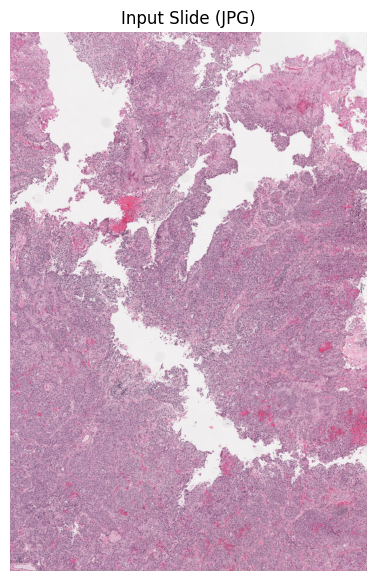

In [8]:
plt.figure(figsize=(5, 7))
plt.imshow(slide)
plt.title('Input Slide (JPG)')
plt.axis('off')
plt.show()


### C2) Patch extraction geometry

For patch size $P$ and stride $S$, index $(i,j)$ maps to:

$$
x_1=jS,\; y_1=iS,\; x_2=x_1+P,\; y_2=y_1+P
$$

with validity constraints $x_2\le W$ and $y_2\le H$.


In [9]:
P = 512
S = 512

coords = []
for i in range((H - P) // S + 1):
    for j in range((W - P) // S + 1):
        x1, y1 = j * S, i * S
        x2, y2 = x1 + P, y1 + P
        coords.append((x1, y1, x2, y2))

print('Total candidate patches:', len(coords))

sample_ids = [1, min(8, len(coords)-1), min(15, len(coords)-1)]
patches = {}
for k, idx in enumerate(sample_ids, start=1):
    x1, y1, x2, y2 = coords[idx]
    patches[f'Patch {k}'] = slide[y1:y2, x1:x2]


Total candidate patches: 40


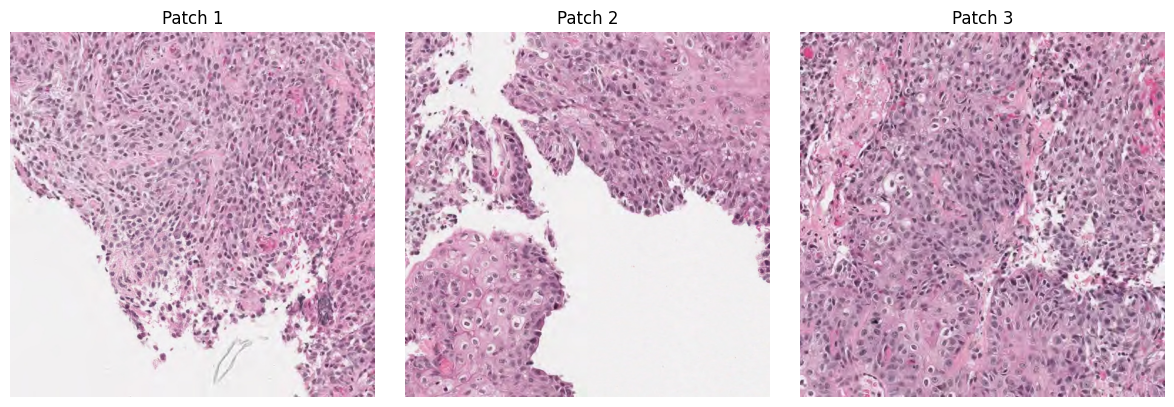

In [10]:
fig, axes = plt.subplots(1, len(patches), figsize=(12, 4))
if len(patches) == 1:
    axes = [axes]

for ax, (name, p) in zip(axes, patches.items()):
    ax.imshow(p)
    ax.set_title(name)
    ax.axis('off')

plt.tight_layout()
plt.show()


### C3) Tissue mask heuristic

Let grayscale patch be $g(x,y)$ and threshold $	au$.

$$
M(x,y)=\mathbf{1}[g(x,y)<	au]
$$

Tissue ratio:

$$
r_{tissue}=\frac{1}{N}\sum_{x,y} M(x,y)
$$


In [11]:
def to_float01(img):
    arr = img.astype(np.float32)
    if arr.max() > 1.5:
        arr = arr / 255.0
    return arr

tau = 0.82
tissue_stats = {}

for name, p in patches.items():
    p = to_float01(p)
    gray = p.mean(axis=2)
    mask = gray < tau
    tissue_stats[name] = {
        'gray': gray,
        'mask': mask,
        'tissue_ratio': float(mask.mean())
    }

for name, st in tissue_stats.items():
    print(name, 'tissue_ratio =', round(st['tissue_ratio'], 3))


Patch 1 tissue_ratio = 0.595
Patch 2 tissue_ratio = 0.528
Patch 3 tissue_ratio = 0.89


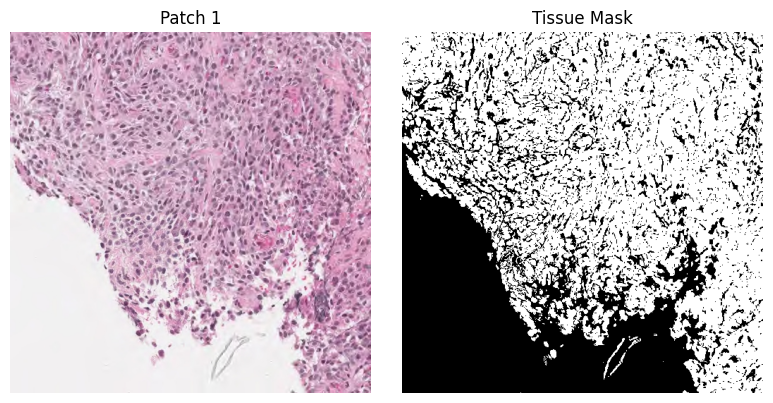

In [12]:
example = list(patches.keys())[0]
p = to_float01(patches[example])
mask = tissue_stats[example]['mask']

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(p)
ax[0].set_title(example)
ax[0].axis('off')
ax[1].imshow(mask, cmap='gray')
ax[1].set_title('Tissue Mask')
ax[1].axis('off')
plt.tight_layout()
plt.show()


### C4) Optical density (stain-intensity intuition)

For normalized intensity $I\in(0,1]$:

$$
OD=-\log(I+\epsilon)
$$


In [13]:
eps = 1e-6

def rgb_to_od(img_float01):
    return -np.log(np.clip(img_float01, eps, 1.0))

for name, p in patches.items():
    od = rgb_to_od(to_float01(p))
    print(name, 'mean OD [R,G,B] =', np.round(od.mean(axis=(0, 1)), 3))


Patch 1 mean OD [R,G,B] = [0.212 0.385 0.261]
Patch 2 mean OD [R,G,B] = [0.193 0.358 0.243]
Patch 3 mean OD [R,G,B] = [0.319 0.571 0.383]


### C5) Focus score (bug-fixed)

We estimate sharpness by gradient energy:

$$
s = \frac{1}{N}\sum_{x,y}\left((\partial_x g)^2 + (\partial_y g)^2
\right)
$$

**Important implementation detail**
- $\partial_x g$ and $\partial_y g$ have different shapes after finite differences.
- We align them on common interior pixels before summation.


In [14]:
def focus_score(gray):
    gx = np.diff(gray, axis=1)   # shape (H, W-1)
    gy = np.diff(gray, axis=0)   # shape (H-1, W)

    # Align both to common interior shape (H-1, W-1)
    gx_c = gx[:-1, :]
    gy_c = gy[:, :-1]

    return float(np.mean(gx_c**2 + gy_c**2))

for name, st in tissue_stats.items():
    score = focus_score(st['gray'])
    print(f'{name} focus_score = {score:.6f}')


Patch 1 focus_score = 0.009620
Patch 2 focus_score = 0.006406
Patch 3 focus_score = 0.010966


### C6) Build patch-level feature table

Each patch gets a compact feature vector:
- mean brightness
- contrast
- tissue ratio
- focus score


In [15]:
feature_rows = []
for name, st in tissue_stats.items():
    gray = st['gray']
    row = {
        'patch': name,
        'mean_brightness': float(gray.mean()),
        'contrast': float(gray.std()),
        'tissue_ratio': float(st['tissue_ratio']),
        'focus_score': float(focus_score(gray)),
    }
    feature_rows.append(row)

print('Patch-level feature table:')
for r in feature_rows:
    print(r)

X_patch = np.array([
    [r['mean_brightness'], r['contrast'], r['tissue_ratio'], r['focus_score']]
    for r in feature_rows
])
print('Feature matrix shape (n_patches, n_features):', X_patch.shape)

Patch-level feature table:
{'patch': 'Patch 1', 'mean_brightness': 0.7711974382400513, 'contrast': 0.15213029086589813, 'tissue_ratio': 0.5949630737304688, 'focus_score': 0.009619849734008312}
{'patch': 'Patch 2', 'mean_brightness': 0.7888813018798828, 'contrast': 0.158534973859787, 'tissue_ratio': 0.5283355712890625, 'focus_score': 0.006406102795153856}
{'patch': 'Patch 3', 'mean_brightness': 0.6730986833572388, 'contrast': 0.132217675447464, 'tissue_ratio': 0.8900489807128906, 'focus_score': 0.010966004803776741}
Feature matrix shape (n_patches, n_features): (3, 4)


## Final Summary

You now have one integrated foundations notebook covering:
1. Clinical decision framing and metric math
2. Core ML model/loss/evaluation intuition
3. Real slide crop analysis with patch-level feature extraction
